# Winning Space Race with Data Science
### IBM Data Science Capstone Project

# Introduction

# SpaceX Falcon 9 First Stage Landing Prediction

This is my data science project based on a case study from the IBM Data Science Professional Certificate course. In this project, I apply data science and machine learning techniques to solve a fictional real-world problem related to SpaceX Falcon 9 first-stage landing success.

The project includes the following deliverables:

- Data Collection using API and web scraping
- Data Wrangling using Pandas
- Exploratory Data Analysis using Pandas and visualization
- Interactive Visual Analytics using Folium and Plotly Dash
- Predictive Analysis using classification models in Scikit-learn

This notebook summarizes my work and learning from the IBM Data Science Capstone Project.

For the complete project files and dashboard code, please visit my [GitHub repository](https://github.com/punampatil258/IBM-SpaceX-Capstone-Project).

In this capstone, I will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because SpaceX can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against SpaceX for a rocket launch. 

In this project, I am a data scientist working for a new rocket company named `Space Y` that would like to compete with SpaceX. My job is to determine the price of each launch by gathering information about SpaceX and creating dashboards. I also determine if SpaceX will reuse the first stage by training a machine learning model and use public information to predict if SpaceX will reuse the first stage.



# Data collection
In this project, I will collect Space X data using the SpaceX API.

### Import Libraries and Define Auxiliary Functions

In [1]:
import requests
import pandas as pd
import numpy as np
import datetime

# Setting this option will print all collumns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)
import os


In [2]:
# Auxiliary lists retained for the original data-collection workflow.
# The final notebook loads the collected IBM dataset below so it does not depend on
# live SpaceX API requests.
def getBoosterVersion(data):
    return data['BoosterVersion'].tolist()

def getLaunchSite(data):
    return data['LaunchSite'].tolist()

def getPayloadData(data):
    return data['PayloadMass'].tolist(), data['Orbit'].tolist()

def getCoreData(data):
    return (
        data['Block'].tolist(), data['ReusedCount'].tolist(), data['Serial'].tolist(),
        data['Outcome'].tolist(), data['Flights'].tolist(), data['GridFins'].tolist(),
        data['Reused'].tolist(), data['Legs'].tolist(), data['LandingPad'].tolist()
    )


### Requesting rocket launch data from SpaceX API

In [3]:
# Load the collected IBM SpaceX dataset
dataset_file = "dataset_part_1.csv"

data_API = pd.read_csv(dataset_file)

data_API.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Cleaning data

In [4]:
# Keep the collected dataset fields used throughout the capstone report.
df_API = data_API.copy()
df_API['Date'] = pd.to_datetime(df_API['Date'])
df_API.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Use auxiliary functions to store data in lists and create a new dataframe

In [5]:
# Global variables retained for compatibility with the original notebook structure.
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
Outcome = []
Flights = []
GridFins = []
Reused = []
Legs = []
LandingPad = []
Block = []
ReusedCount = []
Serial = []
Longitude = []
Latitude = []


In [6]:
# Use the collected columns directly; no live API calls are required.
BoosterVersion = df_API['BoosterVersion'].tolist()
LaunchSite = df_API['LaunchSite'].tolist()
PayloadMass = df_API['PayloadMass'].tolist()
Orbit = df_API['Orbit'].tolist()
Block = df_API['Block'].tolist()
ReusedCount = df_API['ReusedCount'].tolist()
Serial = df_API['Serial'].tolist()
Outcome = df_API['Outcome'].tolist()
Flights = df_API['Flights'].tolist()
GridFins = df_API['GridFins'].tolist()
Reused = df_API['Reused'].tolist()
Legs = df_API['Legs'].tolist()
LandingPad = df_API['LandingPad'].tolist()
Longitude = df_API['Longitude'].tolist()
Latitude = df_API['Latitude'].tolist()


In [7]:
# Keep all required fields used throughout the capstone project.
df_API = df_API[['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
                 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
                 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude',
                 'Latitude', 'Class']]

df_API.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


# Data wrangling

### Filter the dataframe to only include `Falcon 9` launches

In [8]:
# keep only falcon9 launches
df = df_API[df_API['BoosterVersion'] == 'Falcon 9'].copy()

# reset the FlightNumber column
df.loc[:, 'FlightNumber'] = list(range(1, df.shape[0] + 1))
df.reset_index(drop=True, inplace=True)
df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [9]:
df_API['BoosterVersion'].unique()

<ArrowStringArray>
['Falcon 9']
Length: 1, dtype: str

### Dealing with Missing Values

In [10]:
# We can see below that some of the rows are missing values in our dataset
df.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

In [11]:
# Replace missing values in PayloadMass column by its mean value
PayloadMass_mean = df['PayloadMass'].mean()

df['PayloadMass'] = df['PayloadMass'].fillna(PayloadMass_mean)

In [12]:
# The number of missing values of the PayLoadMass column change to zero
df.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

### Create a landing outcome label from Outcome column

In [13]:
# find all landing outcome
landing_outcomes = df['Outcome'].value_counts()
for i,outcome in enumerate(landing_outcomes.keys()):
    print(i,outcome)

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS


In [14]:
# create a set of outcomes where the second stage did not land successfully
bad_outcomes=set(landing_outcomes.keys()[[1,3,5,6,7]])

In [15]:
# identify good and bad outcome
# landing_class = 0 if bad_outcome
# landing_class = 1 otherwise
landing_class = []
for outcome in df['Outcome']:
    if outcome in bad_outcomes:
        landing_class.append(0)
    else:
        landing_class.append(1)

In [16]:
# add to dataframe
df['Class']=landing_class
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Identify data type of each column

In [17]:
df.dtypes

FlightNumber               int64
Date              datetime64[us]
BoosterVersion               str
PayloadMass              float64
Orbit                        str
LaunchSite                   str
Outcome                      str
Flights                    int64
GridFins                    bool
Reused                      bool
Legs                        bool
LandingPad                   str
Block                    float64
ReusedCount                int64
Serial                       str
Longitude                float64
Latitude                 float64
Class                      int64
dtype: object

# Exploratory data analysis

## Pandas

### Calculate the Number of Launches on Each Site

The dataset contains several SpaceX launch facilities, including:

- Cape Canaveral Air Force Station (CCAFS) SLC 40
- Vandenberg Air Force Base (VAFB) SLC 4E
- Kennedy Space Center (KSC) LC 39A

The location of each launch is stored in the `LaunchSite` column.

In [18]:
df['LaunchSite'].value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

### Calculate the Number and Occurrence of Each Orbit

The dataset contains launches to different types of orbits. Some common orbit types include:

- **LEO** – Low Earth Orbit
- **VLEO** – Very Low Earth Orbit
- **GTO** – Geostationary Transfer Orbit
- **SSO** – Sun-Synchronous Orbit
- **ES-L1** – Earth-Sun Lagrange Point 1
- **HEO** – Highly Elliptical Orbit
- **ISS** – International Space Station orbit
- **MEO** – Medium Earth Orbit
- **GEO** – Geostationary Earth Orbit
- **PO** – Polar Orbit
- **SO** – Suborbital Orbit

The `Orbit` column contains the orbit type associated with each SpaceX launch. We will calculate the number of launches for each orbit type to understand the distribution of missions across different orbits.

In [19]:
df['Orbit'].value_counts()

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64

### Find the landing success rate

In [20]:
df["Class"].mean()

np.float64(0.6666666666666666)

## Visualization

### Import visualization library

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

### Visualize the relationship between Payload and Launch Site
Firstly, we want to observe if there is any relationship between launch sites and their payload mass.

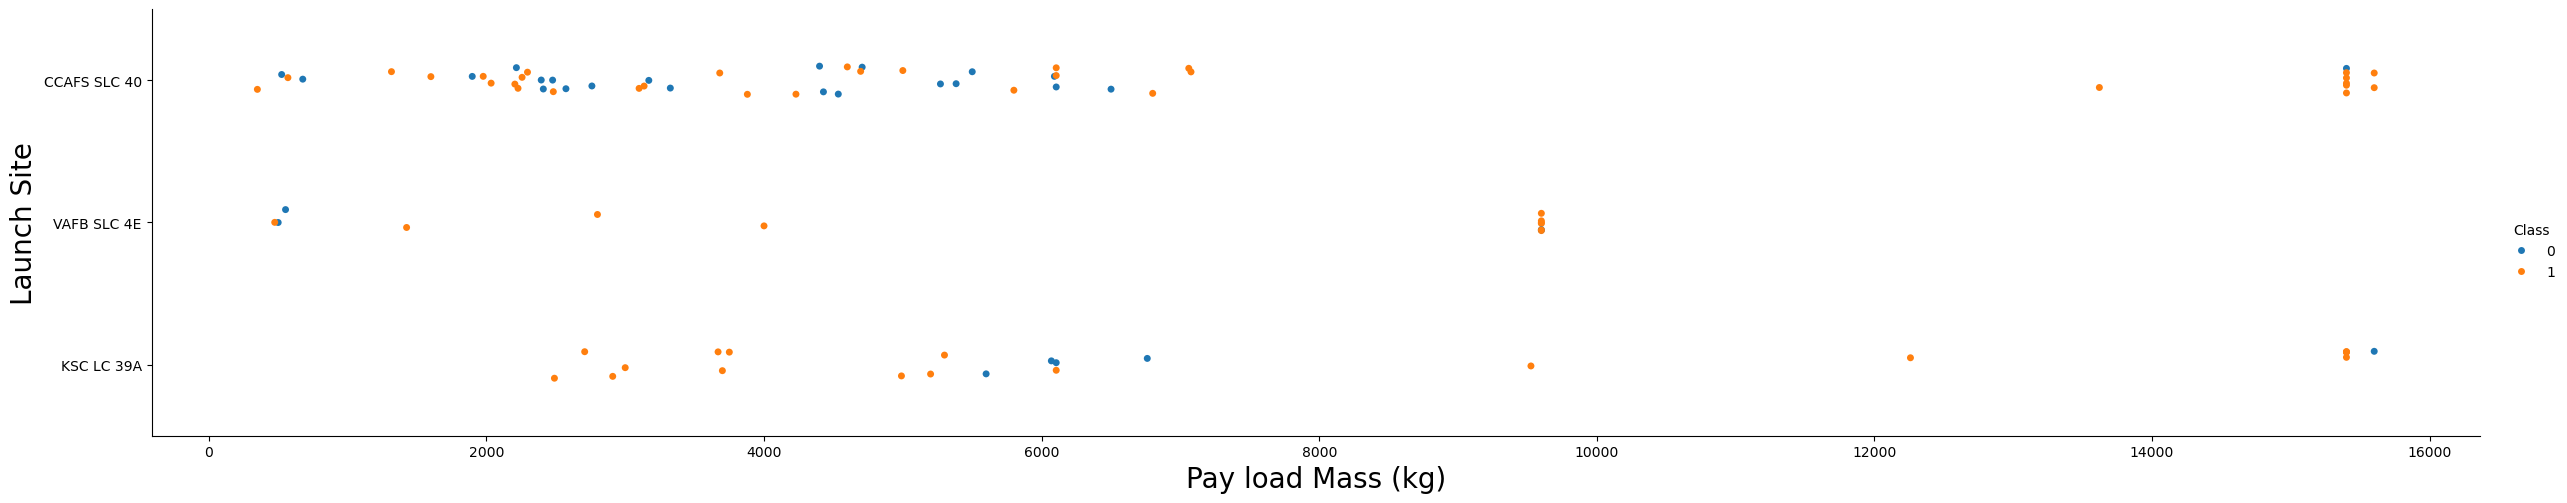

In [22]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Pay load Mass (kg)",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

From Payload Vs. Launch Site scatter point chart, we can see that for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).

### Visualize the relationship between success rate of each orbit type
Next, we want to visually check if there are any relationship between success rate and orbit type using bar chart.

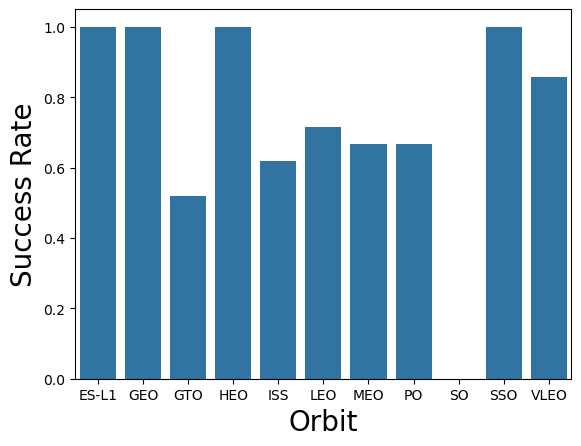

In [23]:
sns.barplot(y="Class", x="Orbit", data=df[['Orbit', 'Class']].groupby(by='Orbit').mean().reset_index())
plt.xlabel("Orbit",fontsize=20)
plt.ylabel("Success Rate",fontsize=20)
plt.show()

We can see that Orbit ES-L1, GEO, HEO, SSO have the best success rate. However, when consider the number of launches to each orbit, the Orbit ES-L1, GEO, HEO, SSO have only 1 launch, so its does not have much integrity. Therefore, after excluding those orbits, the VLEO orbit with the total of 14 launches have the highest success rate.

### Visualize the relationship between Payload and Orbit type
Then, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type.

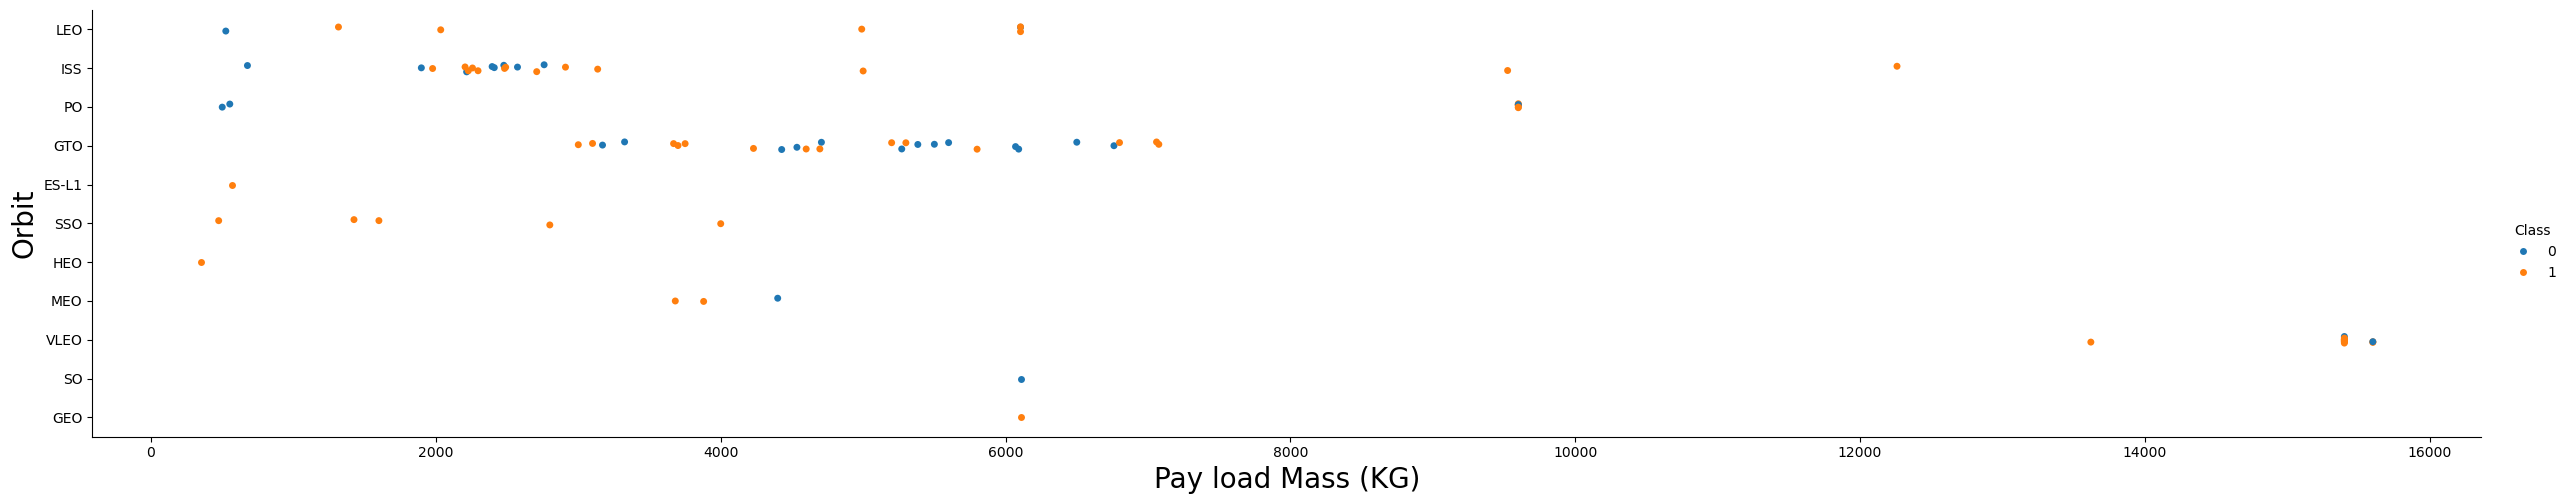

In [24]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Pay load Mass (KG)",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

### Observation

The visualization shows that successful landings are more common for heavier payloads in **Polar, LEO, and ISS orbits**.

For **GTO (Geostationary Transfer Orbit)**, the landing outcome is less clearly distinguishable because both successful and unsuccessful landings occur across different payload masses.

### Visualize the launch success yearly trend
Lastly, we want to visually check if there are any launch success yearly trend using line plot.

In [25]:
# A function to Extract years from the date
def Extract_year(date):
    return [pd.Timestamp(i).year for i in date['Date']]


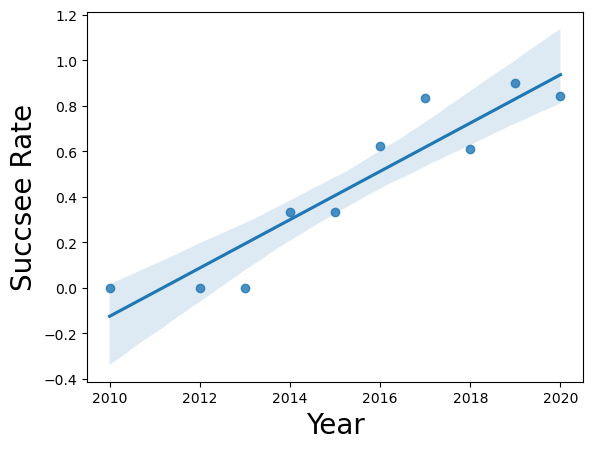

In [26]:
year =[]
df['Year'] = Extract_year(df)
sns.regplot(y="Class", x="Year", data=df[['Year', 'Class']].groupby('Year').mean().reset_index())
plt.xlabel("Year",fontsize=20)
plt.ylabel("Succsee Rate",fontsize=20)
plt.show()

As we can see above, the success rate tend to improve as the year pass.

# Interactive visual analytics

## Folium Map

### Import folium library

In [27]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [28]:
import folium
# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium DivIcon plugin
from folium.features import DivIcon

### Data wrangling

In [29]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
df_folium = df[['LaunchSite', 'Latitude', 'Longitude', 'Class']]
df_launch_sites = df_folium.groupby(['LaunchSite'], as_index=False).first()
df_launch_sites = df_launch_sites[['LaunchSite', 'Latitude', 'Longitude']]
df_launch_sites

,LaunchSite,Latitude,Longitude
0,CCAFS SLC 40,28.561857,-80.577366
1,KSC LC 39A,28.608058,-80.603956
2,VAFB SLC 4E,34.632093,-120.610829


Above coordinates are just plain numbers that can not give any intuitive insights about where are those launch sites. 

Hence, let's visualize those locations by pinning them on a map.

### Mark all launch sites on a map

In [30]:
# Initial the map
site_map = folium.Map(location = [29.559684888503615, -95.0830971930759],
                      zoom_start = 4,
                      max_bounds=True)

In [31]:
# Add a circle and label for each launch site
for i, LaunchSite in enumerate(df_launch_sites['LaunchSite']):
    
    circle = folium.Circle(
        df_launch_sites.loc[i, 'Latitude':'Longitude'].to_list(),
        radius=100,
        color='#d35400',
        fill=True
    ).add_child(folium.Popup(LaunchSite))
    
    site_map.add_child(circle)

    marker = folium.map.Marker(
        df_launch_sites.loc[i, 'Latitude':'Longitude'].to_list(),
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html='<div style="font-size: 12px; color:#d35400;"><b>%s</b></div>' % LaunchSite
        )
    )
    
    site_map.add_child(marker)

site_map

After exploring the map by zoom-in/out the marked areas, we can see that
*   All launch sites in proximity to the Equator line
*   All launch sites in very close proximity to the coast

### Mark the success/failed launches for each site on the map
Next, let's try to enhance the map by adding the launch outcomes for each site, and see which sites have high success rates.
Since a launch only happens in one of the three launch sites, which means many launch records will have the exact same coordinate. Marker clusters can be a good way to simplify a map containing many markers having the same coordinate.


In [32]:
def assign_marker_color(launch_outcome):
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'

df_folium['marker_color'] = df_folium['Class'].apply(assign_marker_color)

In [33]:
# Create marker cluster object
marker_cluster = MarkerCluster()

# Add marker_cluster to current site_map
site_map.add_child(marker_cluster)

# create a Marker object with its coordinate 
# and customize the Marker's icon property to indicate if this launch was successed or failed
for index, row in df_folium.iterrows():
    # Create and add a Marker cluster to the site map
    marker = folium.map.Marker([row['Latitude'], row['Longitude']]
        ,
        # Create an icon as a text label
        icon=folium.Icon(color='white', icon_color=row['marker_color'])
                              )
    marker_cluster.add_child(marker)
    
    site_map

In [34]:
# Set the location and zoom position to Launch Site CCSFS SLC 40
# You can click the marker cluster (Yellow) to find all launch results
location_CCSFS_SLC_40 = [28.561857, -80.577366]
bound = [0.001, 0.001]
sw = list(np.subtract(location_CCSFS_SLC_40, bound))
ne = list(np.add(location_CCSFS_SLC_40, bound))
site_map.fit_bounds([sw, ne])
site_map

From the color-labeled markers in marker clusters, you should be able to easily identify which launch sites have relatively high success rates.

## Plotly Dashboard

The Plotly Dash dashboard provides an interactive visual analysis of SpaceX launch data.

The dashboard includes four main components:

- **Launch Site Dropdown:** Select a specific launch site for analysis.
- **Pie Chart:** Visualize the successful and unsuccessful launch outcomes.
- **Payload Range Slider:** Filter launches based on payload mass.
- **Scatter Plot:** Analyze the relationship between launch site, payload mass, and booster version.

The dashboard is implemented using **Plotly Dash** and can be run locally using the Dash application code included in this project.

For the complete dashboard implementation, please refer to the `spacex-dash-app.ipynb` notebook included in this repository.

# Predict analysis

We will determine if the first stage rocket will land using predictive analysis by classification models.

### Import Libraries and Define Auxiliary Functions

In [35]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [36]:
# This function is to plot the confusion matrix
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])

### Features Selection
From the exploratory data analysis, we obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction.

In [37]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


#### Create dummy variables to categorical columns
Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. 

In [38]:
features_one_hot = pd.get_dummies(features[['Orbit', 'LaunchSite', 'LandingPad', 'Serial']])
features_one_hot.head()

,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


#### Merge dummy variable to the feature

In [39]:
X = features.merge(features_one_hot, left_index=True, right_index=True)
X.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


#### Drop duplicate feature

In [40]:
X.drop(['Orbit', 'LaunchSite', 'LandingPad', 'Serial'], axis=1, inplace=True)

#### Cast all numeric columns to `float64`

In [41]:
X = X.astype('float64')
X.dtypes


FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

#### Select target variable
The target variable is `Class` column from the `df` dataframe

In [42]:
Y = df['Class'].to_numpy()

### Preprocessing dataset
#### Standardize the data in <code>X</code>

In [43]:
scaler = preprocessing.StandardScaler()
scaler.fit(X)
X=scaler.transform(X)

#### split the data `X` and `Y` into training and test data
For the consistency of this report, I set `random_state=2`

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

we can see we only have 18 test samples.

In [45]:
Y_test.shape

(18,)

### Model training
#### Logistic Regression
Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [46]:
# parameters for logistic regression model
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

# create model and tune hyperparameter
lr=LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
logreg_cv_score = logreg_cv.score(X_test, Y_test)
print("Logistic Regression model")
print("tuned hypererparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy (train data):",logreg_cv.best_score_)
print("accuracy (test data):",logreg_cv_score)

Logistic Regression model
tuned hypererparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy (train data): 0.8214285714285714
accuracy (test data): 0.8333333333333334


Then, create a confusion matrix of logistic regression model

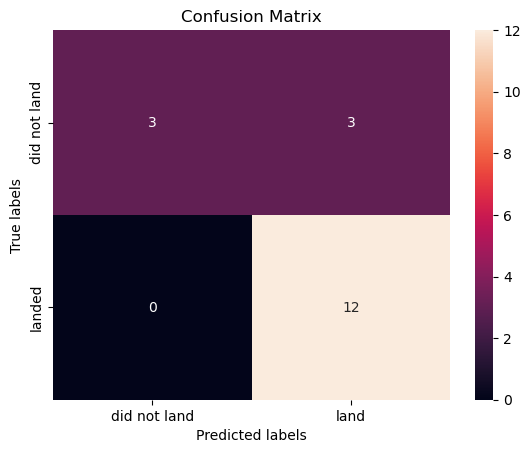

In [47]:
# create confusion matrix
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

From the above result, we see that logistic regression model can distinguish between the different classes with the accuracy of 83.33%.  However, the major problem is false positives.

#### Support Vector Machine (SVM)
Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv - 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [48]:
# Parameters for SVM model
parameters = {
    'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

# Create model and tune hyperparameters
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)

svm_cv.fit(X_train, Y_train)

svm_cv_score = svm_cv.score(X_test, Y_test)

print("Support Vector Machine model")
print("Tuned hyperparameters (best parameters):", svm_cv.best_params_)
print("Accuracy (train data):", svm_cv.best_score_)
print("Accuracy (test data):", svm_cv_score)

Support Vector Machine model
Tuned hyperparameters (best parameters): {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Accuracy (train data): 0.8482142857142858
Accuracy (test data): 0.8333333333333334


Then, create a confusion matrix of SVM model

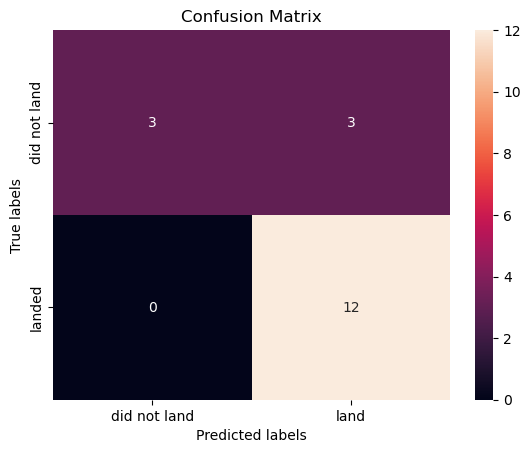

In [49]:
# create confusion matrix
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

From the above result, we see that SVM model can distinguish between the different classes with the accuracy of 83.33%.  However, the major problem is false positives.

#### Decision Tree Classifier
Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [50]:
# parameters for decision tree classifier model
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': [None, 'sqrt', 'log2'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

# create model and tune hyperparameter
tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
tree_cv_score = tree_cv.score(X_test, Y_test)
print("Decision Tree Classifier model")
print("tuned hpyerparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy (train data):", tree_cv.best_score_)
print("accuracy (test data):", tree_cv_score)


Decision Tree Classifier model
tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
accuracy (train data): 0.8589285714285714
accuracy (test data): 0.7777777777777778


Then, create a confusion matrix of decision tree classifier model

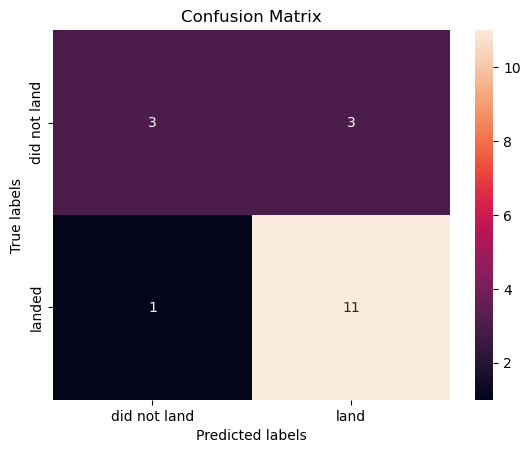

In [51]:
# create confusion matrix
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

From the above result, we see that decision tree classifier model can distinguish between the different classes with the accuracy of 77.78%. However, the major problem is false positives.

#### K Nearest Neighbors
Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [52]:
# Parameters for K-Nearest Neighbors model
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# Create model and tune hyperparameters
KNN = KNeighborsClassifier()

knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

knn_cv_score = knn_cv.score(X_test, Y_test)

print("K Nearest Neighbors model")
print("Tuned hyperparameters (best parameters):", knn_cv.best_params_)
print("Accuracy (train data):", knn_cv.best_score_)
print("Accuracy (test data):", knn_cv_score)

K Nearest Neighbors model
Tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Accuracy (train data): 0.8339285714285714
Accuracy (test data): 0.8333333333333334


Then, create a confusion matrix of k nearest neighbors model

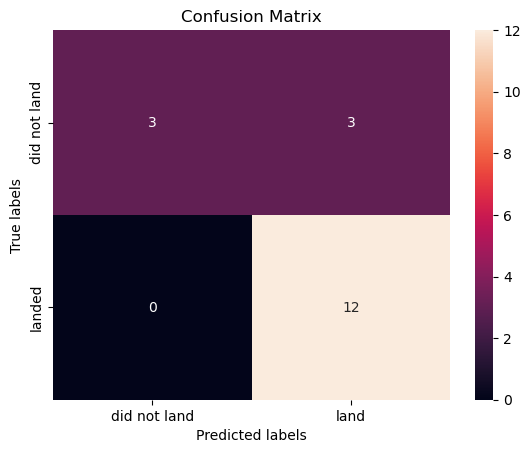

In [53]:
# create confusion matrix
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

From the above result, we see that k nearest neighbors model can distinguish between the different classes with the accuracy of 83.33%. However, the major problem is false positives.

### Compare model performance
Compare each model accuracy on test data using dataframe and bar chart.

In [54]:
# model accuracy dataframe
model_dict = {"Model": ['Logistic Regression', 'Support Vector Machine', 'Decision Tree Classifier', 'K Nearest Neighbors'], 
              "Accuracy": [logreg_cv_score, svm_cv_score, tree_cv_score, knn_cv_score]}
model = pd.DataFrame(model_dict)
model

,Model,Accuracy
0,Logistic Regression,0.833333
1,Support Vector Machine,0.833333
2,Decision Tree Classifier,0.777778
3,K Nearest Neighbors,0.833333


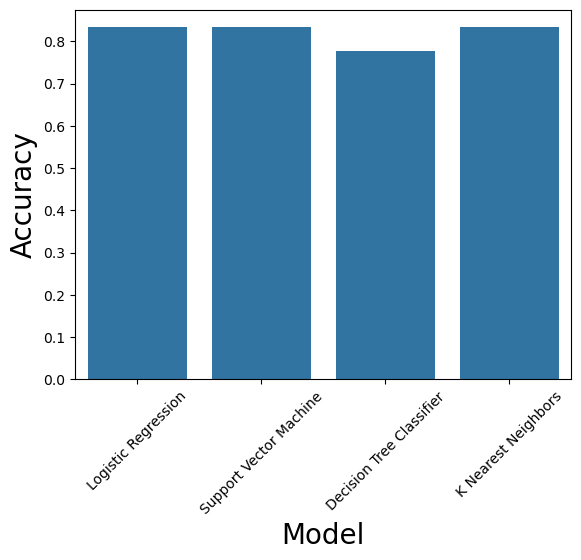

In [55]:
# Model accuracy comparison bar chart
sns.barplot(y="Accuracy", x="Model", data=model)

plt.xticks(rotation=45)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Accuracy", fontsize=20)
plt.show()

In [56]:
tree_cv_score = tree_cv.score(X_test, Y_test)

print("Decision Tree Classifier model")
print("Tuned hyperparameters:", tree_cv.best_params_)
print("Accuracy (train data):", tree_cv.best_score_)
print("Accuracy (test data):", tree_cv_score)

Decision Tree Classifier model
Tuned hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy (train data): 0.8589285714285714
Accuracy (test data): 0.7777777777777778


### Machine Learning Conclusion

Therefore, the results show that **Logistic Regression, Support Vector Machine, and K-Nearest Neighbors achieved the highest test accuracy of 83.33%**. The Decision Tree Classifier achieved a test accuracy of 77.78%.


# Conclusion

This project demonstrates a complete data science workflow for analyzing SpaceX Falcon 9 launch data and predicting landing success.

The main project deliverables are summarized below:

* **Data Collection**

  * Used the collected IBM SpaceX dataset containing launch, booster, payload, orbit, and landing information.

* **Data Wrangling using Pandas**

  * Filtered the dataset to include only `Falcon 9` launches.
  * Replaced missing values in the `PayloadMass` column with its mean value.
  * Created a binary landing outcome label using the `Outcome` column.

* **Exploratory Data Analysis**

  * Analyzed the number of launches by launch site and orbit.
  * Calculated the landing success rate.
  * Identified trends and relationships using Pandas and visualization techniques.

* **Interactive Visual Analytics using Folium and Plotly Dash**

  * Created a Folium map showing SpaceX launch sites and landing outcomes.
  * Used marker clusters to visualize successful and unsuccessful launches.
  * Created an interactive Plotly Dash dashboard with a launch-site dropdown, payload-range slider, and visualization charts.

* **Predictive Analysis using Scikit-learn**

  * Applied one-hot encoding to categorical features.
  * Normalized features using `StandardScaler`.
  * Split the data into training and testing sets.
  * Trained Logistic Regression, Support Vector Machine, Decision Tree Classifier, and K-Nearest Neighbors models.
  * Tuned hyperparameters using `GridSearchCV`.
  * Evaluated model performance using test accuracy and confusion matrices.
  * Compared the performance of all classification models using a table and bar chart.

Overall, this project demonstrates the application of data collection, data wrangling, exploratory data analysis, interactive visualization, and machine learning techniques to investigate and predict SpaceX Falcon 9 landing success.

**Thank you**
